In [30]:
%pip install japanize-matplotlib
import japanize_matplotlib

Note: you may need to restart the kernel to use updated packages.


In [31]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

# いま動いている場所（notebooks/ になっていればOK）
print("CWD:", Path.cwd())

# notebooks/ の1つ上がプロジェクト直下
ROOT = Path.cwd().parent
TABLES = ROOT / "outputs" / "tables"
FIGS = ROOT / "outputs" / "figures"

print("ROOT:", ROOT)
print("TABLES:", TABLES)
print("FIGS:", FIGS)

# 保存先フォルダ作成
FIGS.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

CWD: /Users/yama/Documents/real_estate_open_data/notebooks
ROOT: /Users/yama/Documents/real_estate_open_data
TABLES: /Users/yama/Documents/real_estate_open_data/outputs/tables
FIGS: /Users/yama/Documents/real_estate_open_data/outputs/figures


In [32]:
trend_all_path = TABLES / "trend_all.csv"
price_n30_path = TABLES / "price_by_district_n30.csv"
trend_top5_path = TABLES / "trend_top5_district.csv"

print("trend_all exists:", trend_all_path.exists())
print("price_by_district_n30 exists:", price_n30_path.exists())
print("trend_top5_district exists:", trend_top5_path.exists())

df_trend_all = pd.read_csv(trend_all_path)
df_price_n30 = pd.read_csv(price_n30_path)
df_trend_top5 = pd.read_csv(trend_top5_path)

display(df_trend_all.head())
display(df_price_n30.head())
display(df_trend_top5.head())

print("df_trend_all columns:", list(df_trend_all.columns))
print("df_price_n30 columns:", list(df_price_n30.columns))
print("df_trend_top5 columns:", list(df_trend_top5.columns))

trend_all exists: True
price_by_district_n30 exists: True
trend_top5_district exists: True


,quarter_key,n,median_man,mean_man
0,2022Q2,226,100.000000,103.240915
1,2022Q3,190,104.880952,106.916209
2,2022Q4,216,102.500000,107.699724
3,2023Q1,242,110.000000,113.499407
4,2023Q2,213,105.714286,110.487371


,地区名,n,median_man,mean_man,median_price,median_area
0,上大崎,192,164.575163,179.857250,87500000.0,55.0
1,小山,132,150.000000,148.593544,86500000.0,60.0
2,大崎,206,146.410256,149.792102,92000000.0,65.0
3,西五反田,387,128.888889,135.651685,70000000.0,55.0
4,戸越,53,123.076923,117.903646,51000000.0,45.0


,地区名,quarter_key,n,median_man
0,上大崎,2022Q2,15,177.777778
1,上大崎,2022Q3,7,168.421053
2,上大崎,2022Q4,15,130.000000
3,上大崎,2023Q1,13,208.571429
4,上大崎,2023Q2,14,150.219780


df_trend_all columns: ['quarter_key', 'n', 'median_man', 'mean_man']
df_price_n30 columns: ['地区名', 'n', 'median_man', 'mean_man', 'median_price', 'median_area']
df_trend_top5 columns: ['地区名', 'quarter_key', 'n', 'median_man']


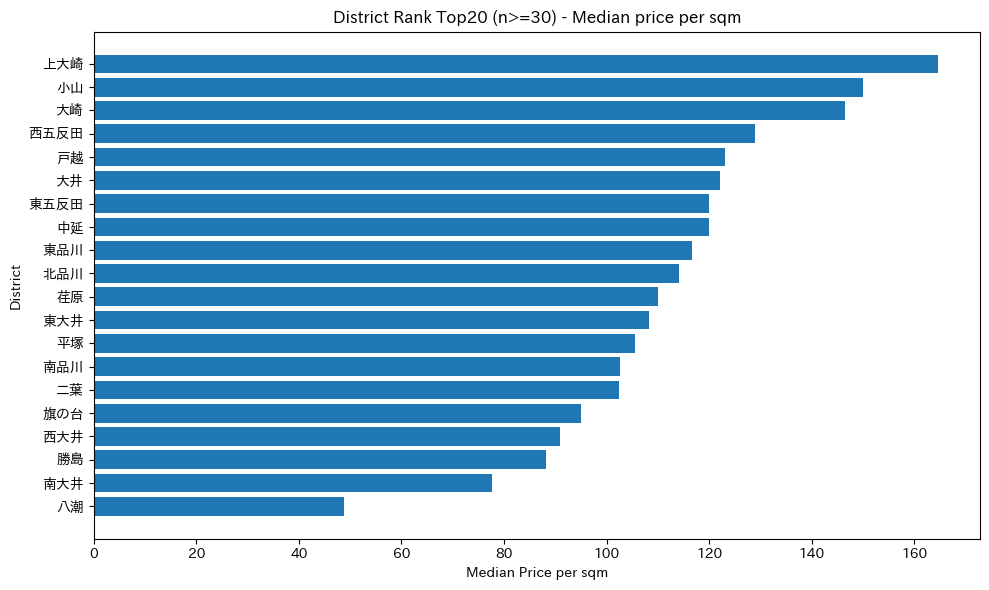

saved: /Users/yama/Documents/real_estate_open_data/outputs/figures/district_rank_top20.png


In [33]:
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"列が見つかりません。候補={candidates} / columns={list(df.columns)}")

# 地区名っぽい列
district_col = pick_col(df_price_n30, ["district", "district_name", "地区", "町名", "地区名", "name"])
# 中央値（万円/㎡）っぽい列（あなたのデータは median_man の可能性が高い）
value_col = pick_col(df_price_n30, ["median_man", "median_price_per_sqm", "median", "median_value"])

# Top20（高い順）
top20 = df_price_n30.sort_values(value_col, ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(top20[district_col][::-1], top20[value_col][::-1])
plt.title("District Rank Top20 (n>=30) - Median price per sqm")
plt.xlabel("Median Price per sqm")
plt.ylabel("District")
plt.tight_layout()

out_path = FIGS / "district_rank_top20.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print("saved:", out_path)

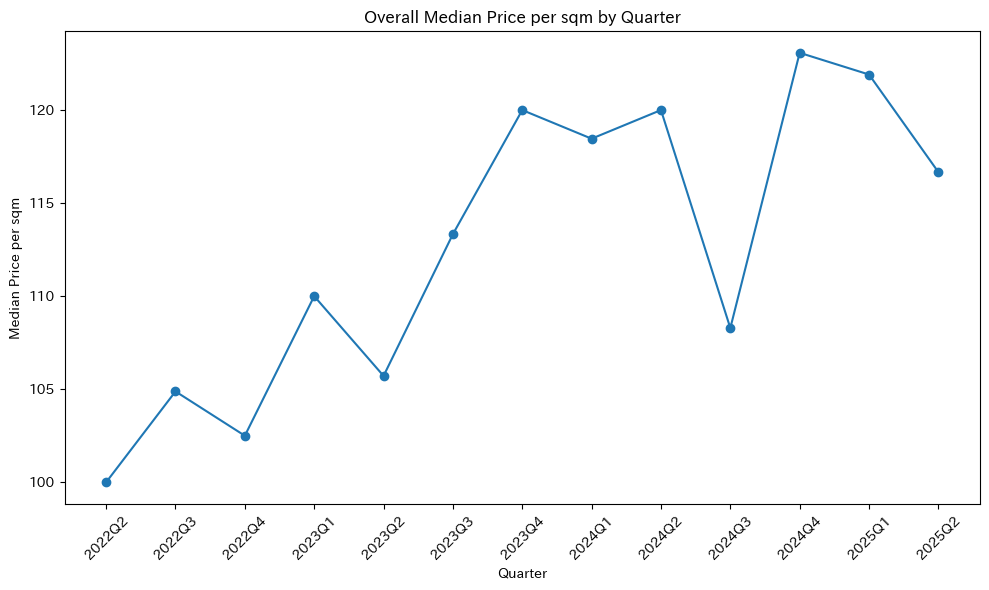

saved: /Users/yama/Documents/real_estate_open_data/outputs/figures/trend_all_median.png


In [34]:
# 四半期キー列
q_col = pick_col(df_trend_all, ["quarter_key", "year_quarter", "quarter", "q"])
# 中央値列
med_col = pick_col(df_trend_all, ["median_man", "median_price_per_sqm", "median", "median_value"])

df_trend_all_sorted = df_trend_all.sort_values(q_col)

plt.figure(figsize=(10, 6))
plt.plot(df_trend_all_sorted[q_col], df_trend_all_sorted[med_col], marker="o")
plt.title("Overall Median Price per sqm by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Median Price per sqm")
plt.xticks(rotation=45)
plt.tight_layout()

out_path = FIGS / "trend_all_median.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print("saved:", out_path)

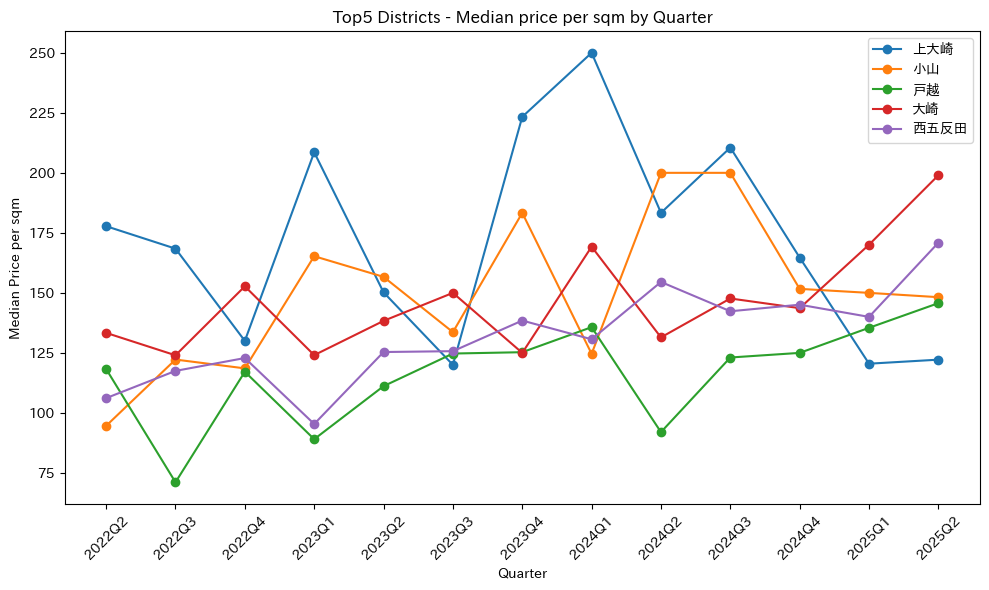

saved: /Users/yama/Documents/real_estate_open_data/outputs/figures/trend_top5_median.png


In [35]:
# 四半期・地区・中央値の列を推定
q_col = pick_col(df_trend_top5, ["quarter_key", "year_quarter", "quarter", "q"])
district_col = pick_col(df_trend_top5, ["district", "district_name", "地区", "町名", "地区名", "name"])
med_col = pick_col(df_trend_top5, ["median_man", "median_price_per_sqm", "median", "median_value"])

df_top5_sorted = df_trend_top5.sort_values(q_col)

plt.figure(figsize=(10, 6))
for d in df_top5_sorted[district_col].dropna().unique():
    sub = df_top5_sorted[df_top5_sorted[district_col] == d]
    plt.plot(sub[q_col], sub[med_col], marker="o", label=str(d))

plt.title("Top5 Districts - Median price per sqm by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Median Price per sqm")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

out_path = FIGS / "trend_top5_median.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print("saved:", out_path)

In [36]:
targets = [
    FIGS / "district_rank_top20.png",
    FIGS / "trend_all_median.png",
    FIGS / "trend_top5_median.png",
]
for p in targets:
    print(p.name, "exists=", p.exists(), "size=", (p.stat().st_size if p.exists() else None))

district_rank_top20.png exists= True size= 71905
trend_all_median.png exists= True size= 105334
trend_top5_median.png exists= True size= 234430
